# Chest X-ray Pneumonia Classification

## 1. Setup
Install/import dependencies and configure the experiment.

In [2]:
!pip -q install tensorflow seaborn scikit-learn opencv-python

import os
import random
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

print(tf.__version__)

2.20.0


# Kaggle Dataset Mount

In [3]:
import os
import zipfile
from pathlib import Path

# Create Kaggle config folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json into the correct place
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Install Kaggle API
!pip -q install kaggle

# Download dataset from Kaggle
DATASET_SLUG = "paultimothymooney/chest-xray-pneumonia"   # change if using another chest x-ray dataset
DOWNLOAD_DIR = Path("/content/kaggle_dataset")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d {DATASET_SLUG} -p /content/kaggle_dataset

# Unzip downloaded file
zip_files = list(DOWNLOAD_DIR.glob("*.zip"))
for zf in zip_files:
    with zipfile.ZipFile(zf, "r") as zip_ref:
        zip_ref.extractall(DOWNLOAD_DIR)

print("Dataset downloaded and extracted to:", DOWNLOAD_DIR)

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:58<00:00, 20.8MB/s]

Dataset downloaded and extracted to: /content/kaggle_dataset


## Config

In [5]:
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_HEAD = 8
EPOCHS_FINE = 10

AUTOTUNE = tf.data.AUTOTUNE

OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_ROOT = Path("/content/kaggle_dataset/chest_xray")

print("Using dataset root:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Using dataset root: /content/kaggle_dataset/chest_xray
Exists: True


## Inspect the dataset folder

In [6]:
def find_subdir(root: Path, name: str):
    candidates = [root / name, root / name.lower(), root / name.upper(), root / name.capitalize()]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    return None

def list_class_counts(folder: Path):
    counts = {}
    for cls_dir in sorted([p for p in folder.iterdir() if p.is_dir()]):
        counts[cls_dir.name] = len([f for f in cls_dir.iterdir() if f.is_file()])
    return counts

def print_folder_summary(root: Path):
    print(f"Dataset root: {root}")
    if not root.exists():
        raise FileNotFoundError(f"Dataset root not found: {root}")
    for split_name in ["train", "val", "validation", "test"]:
        split_dir = find_subdir(root, split_name)
        if split_dir:
            print(f"\n[{split_dir.name}]")
            for cls, count in list_class_counts(split_dir).items():
                print(f"  {cls}: {count}")

print_folder_summary(DATASET_ROOT)

Dataset root: /content/kaggle_dataset/chest_xray

[train]
  NORMAL: 1341
  PNEUMONIA: 3875

[val]
  NORMAL: 8
  PNEUMONIA: 8

[test]
  NORMAL: 234
  PNEUMONIA: 390


## Load train, validation, test datasets

In [7]:
def make_datasets():
    train_dir = find_subdir(DATASET_ROOT, "train")
    test_dir = find_subdir(DATASET_ROOT, "test")
    val_dir = find_subdir(DATASET_ROOT, "val") or find_subdir(DATASET_ROOT, "validation")

    if train_dir is None:
        raise ValueError("No train directory found. Expected dataset_root/train/")
    if test_dir is None:
        print("Warning: no test directory found. Validation set will be used for final evaluation.")

    if val_dir is not None:
        train_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            labels="inferred",
            label_mode="binary",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        val_ds = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            labels="inferred",
            label_mode="binary",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=False,
        )
    else:
        train_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            labels="inferred",
            label_mode="binary",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
            validation_split=0.2,
            subset="training",
        )
        val_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            labels="inferred",
            label_mode="binary",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=False,
            seed=SEED,
            validation_split=0.2,
            subset="validation",
        )

    if test_dir is not None:
        test_ds = tf.keras.utils.image_dataset_from_directory(
            test_dir,
            labels="inferred",
            label_mode="binary",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=False,
        )
    else:
        test_ds = None

    class_names = train_ds.class_names
    print("Class names:", class_names)
    return train_ds, val_ds, test_ds, class_names

train_ds, val_ds, test_ds, class_names = make_datasets()

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']


## Cache/prefetch and class weights

In [8]:
def prepare_for_training(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare_for_training(train_ds)
val_ds = prepare_for_training(val_ds)
if test_ds is not None:
    test_ds = prepare_for_training(test_ds)

def get_class_weights(train_ds):
    y = []
    for _, labels in train_ds.unbatch():
        label = labels.numpy()
        y.append(int(label) if np.ndim(label) == 0 else int(label[0]))
    y = np.array(y)
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}

class_weight = get_class_weights(train_ds)
print(class_weight)

{0: 1.9448173005219984, 1: 0.6730322580645162}


## Augmentation and Model

In [9]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="augmentation",
)

def build_model():
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Lambda(lambda img: preprocess_input(img))(x)

    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="densenet121_transfer")
    return model, base_model

model, base_model = build_model()
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Compile and Train head

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint(str(OUTPUT_DIR / "best_model.keras"), monitor="val_loss", save_best_only=True),
    CSVLogger(str(OUTPUT_DIR / "training_log.csv")),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.8493 - auc: 0.9259 - loss: 0.3481 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.1720 - learning_rate: 0.0010
Epoch 2/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 29s 88ms/step - accuracy: 0.8924 - auc: 0.9592 - loss: 0.2587 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 3/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.9068 - auc: 0.9653 - loss: 0.2376 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 4/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.9095 - auc: 0.9696 - loss: 0.2220 - val_accuracy: 0.9375 - val_auc: 0.9922 - val_loss: 0.1452 - learning_rate: 0.0010
Epoch 5/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.9086 - auc: 0.9704 - loss: 0.2179 - val_accuracy: 0.9375 - val_auc: 0.9922 - val_loss: 0.1426 - learning_rate: 0.0010
Epoch 6/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.9124 - 

## Fine-tune the last layers

In [11]:
base_model.trainable = True

freeze_until = -40  # DenseNet fine-tuning region
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

for layer in base_model.layers[freeze_until:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 68s 116ms/step - accuracy: 0.8873 - auc: 0.9435 - loss: 0.6558 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.1890 - learning_rate: 1.0000e-05
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 31s 96ms/step - accuracy: 0.9216 - auc: 0.9648 - loss: 0.3223 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0900 - learning_rate: 1.0000e-05
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - accuracy: 0.9208 - auc: 0.9730 - loss: 0.2368 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0717 - learning_rate: 1.0000e-05
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 31s 96ms/step - accuracy: 0.9185 - auc: 0.9741 - loss: 0.2273 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0640 - learning_rate: 1.0000e-05
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9214 - auc: 0.9779 - loss: 0.1975 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0628 - learning_rate: 1.0000e-05
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 31s 96ms/

## Merge Histories and Plot Training curves

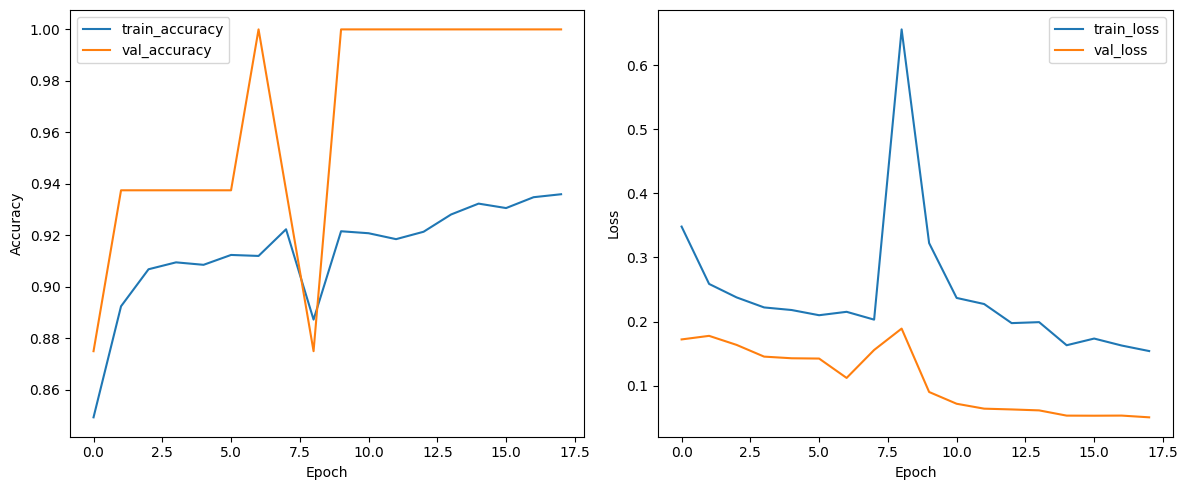

In [12]:
def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for k in keys:
        merged[k] = h1.history.get(k, []) + h2.history.get(k, [])
    history = keras.callbacks.History()
    history.history = merged
    return history

history = merge_histories(history1, history2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history.get("accuracy", []), label="train_accuracy")
plt.plot(history.history.get("val_accuracy", []), label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history.get("loss", []), label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Save the Model

In [13]:
model.save(OUTPUT_DIR / "final_model.keras")
print("Saved model to:", OUTPUT_DIR / "final_model.keras")

Saved model to: /content/output/final_model.keras


## Evaluation Metrics, Confusion matrix, ROC


TEST METRICS
accuracy: 0.8958
precision: 0.9073
recall: 0.9282
f1: 0.9176
auc: 0.9615

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.84      0.86       234
   PNEUMONIA       0.91      0.93      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624



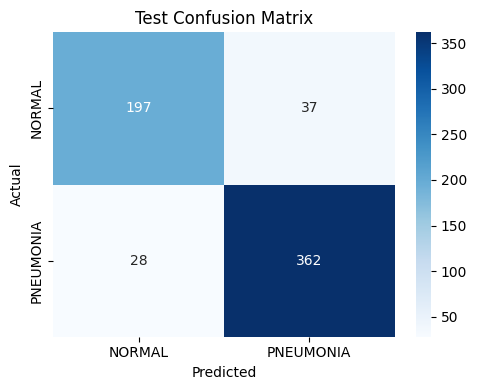

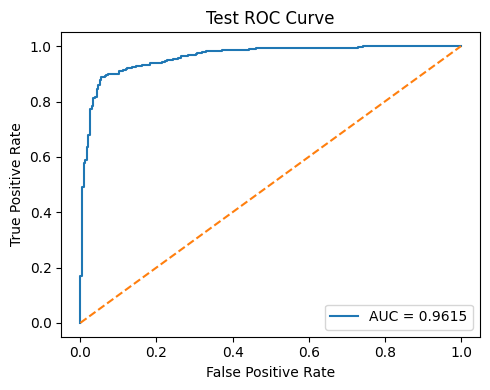

In [14]:
def evaluate_model(model, ds, split_name="test"):
    y_true, y_prob = [], []

    for batch_x, batch_y in ds:
        preds = model.predict(batch_x, verbose=0).ravel()
        y_prob.extend(preds.tolist())
        y_true.extend(batch_y.numpy().ravel().tolist())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }

    print(f"\n{split_name.upper()} METRICS")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NORMAL", "PNEUMONIA"],
        yticklabels=["NORMAL", "PNEUMONIA"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{split_name.capitalize()} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{split_name}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['auc']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.capitalize()} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{split_name}_roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    return metrics, y_true, y_prob, y_pred

eval_ds = test_ds if test_ds is not None else val_ds
split_name = "test" if test_ds is not None else "validation"
metrics, y_true, y_prob, y_pred = evaluate_model(model, eval_ds, split_name=split_name)

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

## Grad-CAM

In [26]:
def get_last_conv_layer_name(backbone_model):
    for layer in reversed(backbone_model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
        try:
            if len(layer.output.shape) == 4 and "conv" in layer.name.lower():
                return layer.name
        except Exception:
            continue
    raise ValueError("No convolutional layer found inside the backbone model.")

def build_head_model(full_model, backbone_output_shape):
    """
    Rebuild the trained classification head using the trained layer objects
    from the full model.
    """
    head_input = keras.Input(shape=backbone_output_shape[1:])

    x = full_model.get_layer("global_average_pooling2d")(head_input)
    x = full_model.get_layer("dropout")(x)
    x = full_model.get_layer("dense")(x)
    x = full_model.get_layer("dropout_1")(x)
    out = full_model.get_layer("dense_1")(x)

    return keras.Model(head_input, out, name="classification_head")

def make_gradcam_heatmap(img_array, backbone_model, head_model, last_conv_layer_name):
    """
    Grad-CAM computed from the backbone model only, then passed through the
    reconstructed classifier head.
    """
    cam_backbone = keras.Model(
        backbone_model.inputs,
        [backbone_model.get_layer(last_conv_layer_name).output, backbone_model.output],
        name="cam_backbone",
    )

    with tf.GradientTape() as tape:
        conv_outputs, backbone_features = cam_backbone(img_array, training=False)
        tape.watch(conv_outputs)

        predictions = head_model(backbone_features, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    return heatmap.numpy()

## Grad-CAM overlay

In [27]:
def save_gradcam_overlay(image_array, heatmap, alpha=0.4, out_path=None):
    import cv2

    image = image_array.copy()
    if image.max() <= 1.0:
        image = image * 255.0
    image = np.clip(image, 0, 255).astype(np.uint8)

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    cmap = plt.get_cmap("jet")
    colored = cmap(np.arange(256))[:, :3]
    colored_heatmap = colored[heatmap]
    colored_heatmap = tf.keras.utils.array_to_img(colored_heatmap)
    colored_heatmap = tf.keras.utils.img_to_array(colored_heatmap)

    overlay = colored_heatmap * alpha + image
    overlay = tf.keras.utils.array_to_img(overlay)

    if out_path is not None:
        overlay.save(out_path)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")
    plt.title("Heatmap")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Overlay")

    plt.tight_layout()
    plt.show()

    return overlay

## Run Grad-CAM on one image

Using Grad-CAM layer: conv5_block16_concat


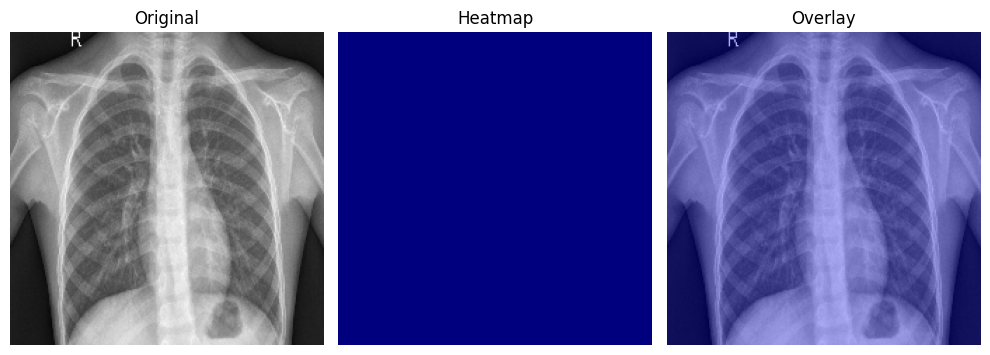

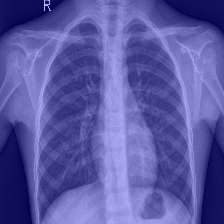

In [28]:
# Take one image from validation/test set
sample_batch = next(iter(eval_ds))
sample_img = sample_batch[0][0]

# DenseNet expects input in the same 0–255 range before preprocess_input
img_tensor = tf.expand_dims(tf.cast(sample_img, tf.float32), axis=0)

# Build Grad-CAM pieces
last_conv_layer_name = get_last_conv_layer_name(base_model)
print("Using Grad-CAM layer:", last_conv_layer_name)

head_model = build_head_model(model, base_model.output_shape)

heatmap = make_gradcam_heatmap(
    img_tensor,
    base_model,
    head_model,
    last_conv_layer_name
)

save_gradcam_overlay(
    sample_img.numpy(),
    heatmap,
    out_path=OUTPUT_DIR / "gradcam_overlay.png",
)

## Save all results in one place

In [29]:
print("Model saved:", OUTPUT_DIR / "final_model.keras")
print("Metrics saved:", OUTPUT_DIR / "metrics.json")
print("Training curves:", OUTPUT_DIR / "training_curves.png")
print("Confusion matrix:", OUTPUT_DIR / f"{split_name}_confusion_matrix.png")
print("ROC curve:", OUTPUT_DIR / f"{split_name}_roc_curve.png")
print("Grad-CAM:", OUTPUT_DIR / "gradcam_overlay.png")

Model saved: /content/output/final_model.keras
Metrics saved: /content/output/metrics.json
Training curves: /content/output/training_curves.png
Confusion matrix: /content/output/test_confusion_matrix.png
ROC curve: /content/output/test_roc_curve.png
Grad-CAM: /content/output/gradcam_overlay.png
